<a href="https://colab.research.google.com/github/adityadhanraj24/Python-A-learning-hub/blob/main/02_Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Neural Network Classification with PyTorch

Classification is a problem of predicting whether something is one thing or another(There can be multiple things as the options).



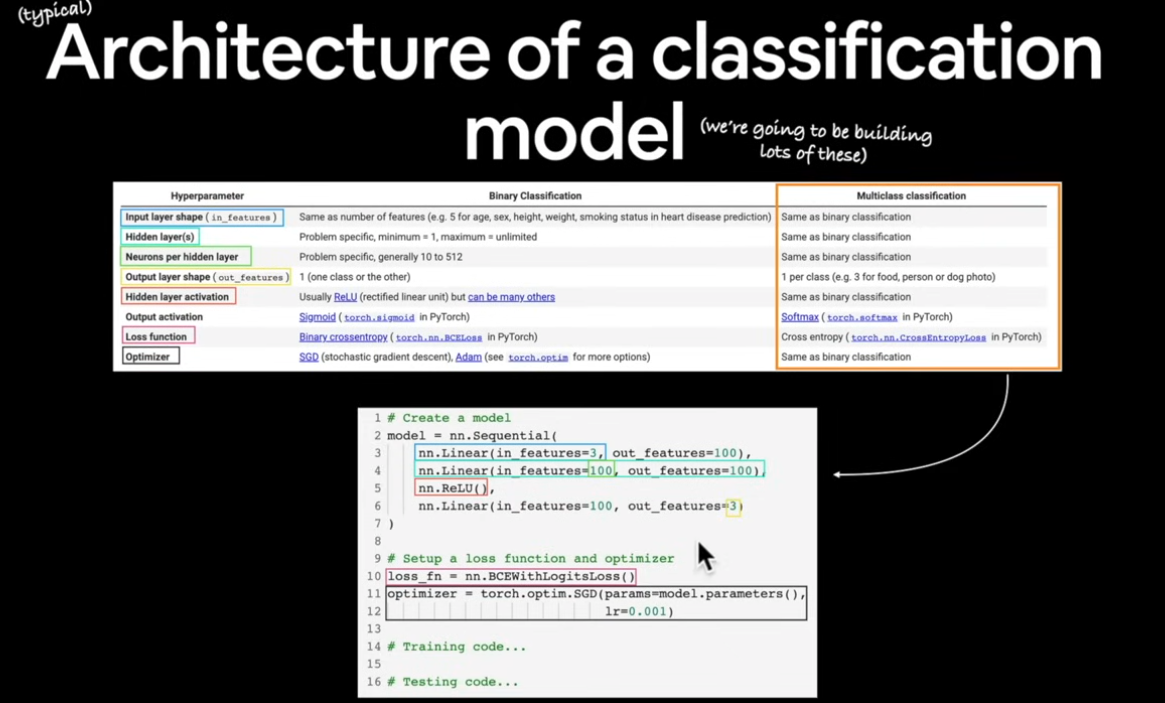

# 1. Make classification data and get it ready

In [2]:
import sklearn

In [3]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples=1000

# Create Circles

X, y = make_circles(n_samples,noise=0.03,random_state=42)

In [4]:
len(X),len(y)

(1000, 1000)

In [5]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of X:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of X:
 [1 1 1 1 0]


In [6]:
# Make Dataframe of circle data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


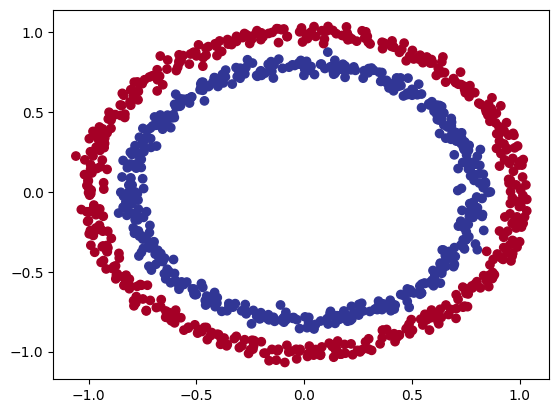

In [7]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);

**Note :** The data we are working with is often reffered to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1  Check input and output shapes

In [8]:
X.shape,y.shape

((1000, 2), (1000,))

In [9]:
# View the first example of features and labels
X_sample=X[0]
y_sample= y[0]

print(f"Values for one sample of X:{X_sample} and the same for y:{y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of X:[0.75424625 0.23148074] and the same for y:1
Shapes for one sample of X: (2,) and the same for y:()


### 1.2 Turn Data into tensors and create train and test splits

In [10]:
import torch
torch.__version__

'2.11.0+cpu'

In [11]:
type(X) , X.dtype

(numpy.ndarray, dtype('float64'))

In [12]:
# Turn data into tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y ,dtype=torch.float32)

X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [13]:
type(X),X.dtype,y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [14]:
torch.manual_seed(42)

In [15]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.2 ,
              # 0.2 =20% of data will be test & 80% will be train
                                                   random_state=42
)


In [16]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [17]:
n_samples

1000

## 2. Building a model

Let's build a model to classify our blue and red dots

To do so ,we want to:

1.   Setup device agonistic code so our code will run on an accelerator(GPU) if there is one
2.   Construct a model (by subclassing nn.Module)
3.  Define a loss function and optimizer
4. Create a training and test loop



In [18]:
# import pytorch and nn

import torch
from torch import nn

device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [19]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we have setup device agnostic code, let's create a model that:

1. Subclasses `nn.module` (almost all models in PyTorch subclass `nn.Module` ).
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target device.


In [20]:
X_train.shape,y_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 0., 0., 1.]))

In [21]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __init__(self) :
    super().__init__()
    # 2. Create 2. nn.Linear layers capable of handling the shapes of our data
    self.layer_1=nn.Linear(in_features=2,out_features=5)  # takes in 2 features and upscales to 5 features
    self.layer_2=nn.Linear(in_features=5,out_features=1)  # Takes in 5 features from previous layer and output a single feature (same shape as y)

    # self.two_linear_layers=nn.Sequential(
    #     nn.Linear(in_features=2,out_features=5),
    #     nn.Linear(in_features=5,out_features=1),
    # )

    #3. Define a forward() method that outlines the forward pass
    def forward(self,x):
      return self.layer_2(self.layer_1(x)) # x -> layer1 -> layer2 -> output
      #  return two_linear_layers(X)

# 4 Instantiate an instance of our model class and send it to the target device

model_0=CircleModelV0().to(device)
model_0





CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [22]:
next(model_0.parameters()).device

device(type='cpu')

In [23]:
# Let's replicate the model above using nn.Sequential()
model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0


Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [25]:
# Make some prediction
with torch.inference_mode():
  untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions :{len(untrained_preds)},Shape:{untrained_preds.shape}")
print(f"Length of test samples :{len(X_test)},Shape:{X_test.shape}")
print(f"\n First 10 predictions : \n{torch.round(untrained_preds[:10])}")
print(f"\n First 10 labels : \n {y_test[:10]}")

Length of predictions :200,Shape:torch.Size([200, 1])
Length of test samples :200,Shape:torch.Size([200, 2])

 First 10 predictions : 
tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]])

 First 10 labels : 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [26]:
y_test[:10],X_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]))

### 2.1 Setup loss function and optimizer
Which loss function or optimizer should you use?
Again... this is problem specific.

For example for regession you might want MAE or MSE (Mean Absolute error or mean squared error).

For classification you might want binary cross entropy or categorical cross entropy (cross entropy).

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many buildin option.

* For the loss function we are going to use `torch.nn.BECWithLogitsLoss()`.
* For the different optimizers see `torch.optim`


`Logit layer :` The layer that feeds in to softmax (or other such normalization). The output of the softmax are the probabilities for the classification task and its input is logits layer.

In [27]:
### 2.1 Setup loss function and optimizer
# loss_fn=nn.BCELoss()

# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )
loss_fn=nn.BCEWithLogitsLoss()  # BCEWithLogitsLoss= sigmoid activation function buildin

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [28]:
# Calculate accuracy - out of 100 examples , what percentage does our model gget right?

def accuracy_fn(y_true,y_pred):
  correct= torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred)) * 100
  return acc



## 3. Train Model

To train our model , we are going to need to build a training steps:
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward(backpopagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits** .
We can convert these **logits** into prediction probabilities by passing them to some kind of activation function(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the **argmax()**.

In [29]:
# View the first 5 outputs of the forward pass on the test data


model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [30]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [31]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities

y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

For our prediction probability values, we need to perform a range-style rounding on them

*   y_pred_probs >=0.5, y=1 (class 1)
*   y_pred_probs <0.5 , y=0 (class 0)





In [32]:
# Find the predicted labels
y_preds=torch.round(y_pred_probs)

# In full
y_pred_labels= torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

# Get rid of extra dimension

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

In [33]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [34]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])

3.2 Buildiing a training and testing loop


In [36]:
torch.manual_seed(42)

# set thhe number of epochs
epochs=100

# put data to target device

X_train , y_train= X_train.to(device), y_train.to(device)
X_test,y_test=X_test.to(device), y_test.to(device)

# Building training and evaluation loop

for epoch in range(epochs):
  ## Training
  model_0.train()

  #1. Forward pass
  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))  # turn logits -> pred probs -> pred labels

  #2. Calculate Loss/accuracy

  loss=loss_fn(y_logits,y_train  # nn.BCEWithLogitsLoss expects raw logits as input
               )
  acc= accuracy_fn(y_true=y_train,
                   y_pred=y_pred)

  # 3. Optimizer zero grad

  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step()
  optimizer.step()

  ### Testing

  model_0.eval()
  with torch.inference_mode():
    # 1. Forward Pass
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    #2. Calculate test loss/acc
    test_loss=loss_fn(test_logits,
                      y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

    # Print out what's happen
  if epoch % 10==0:
    print(f"Epoch : {epoch} | Loss:{loss:.5f},Acc:{acc:2f}% | Test loss:{test_loss:.5f},Test acc:{test_acc:2f}%")




Epoch : 0 | Loss:0.69331,Acc:49.250000% | Test loss:0.69271,Test acc:53.000000%
Epoch : 10 | Loss:0.69327,Acc:49.750000% | Test loss:0.69279,Test acc:54.000000%
Epoch : 20 | Loss:0.69324,Acc:50.250000% | Test loss:0.69286,Test acc:53.000000%
Epoch : 30 | Loss:0.69321,Acc:49.750000% | Test loss:0.69294,Test acc:55.000000%
Epoch : 40 | Loss:0.69319,Acc:50.625000% | Test loss:0.69301,Test acc:54.000000%
Epoch : 50 | Loss:0.69317,Acc:52.250000% | Test loss:0.69307,Test acc:51.000000%
Epoch : 60 | Loss:0.69315,Acc:51.375000% | Test loss:0.69314,Test acc:56.000000%
Epoch : 70 | Loss:0.69314,Acc:51.125000% | Test loss:0.69320,Test acc:52.000000%
Epoch : 80 | Loss:0.69313,Acc:51.250000% | Test loss:0.69325,Test acc:48.500000%
Epoch : 90 | Loss:0.69311,Acc:51.000000% | Test loss:0.69331,Test acc:50.000000%


## 4. Make Predictions and evaluate the model


From the metrics it looks like our model isnot learning anything..

So to inspect it let's make some predictions and make them visual!!

In other words ,"Visualize, visualize!"


To do so , we are going to import `plot_decision_boundary()`

In [37]:
import requests
from pathlib import Path

# Download helper functions from learn PyTorch repo (if it is not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Download helper_functions.py")
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Download helper_functions.py


ModuleNotFoundError: No module named 'helper_functions'